# Data Exploration: Industrial Activity and Ecological Damage
This notebook investigates how industrial activity may relate to ecological damage and whether that relationship depends on economic development. We start with data structure checks, identify candidate variables, reshape the wide dataset, and create clean visual summaries.

In [1]:
# Load libraries and dataset
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', context='notebook')

df = pd.read_csv('merged_raw_all_years.csv')
print('Loaded dataset with rows={}, columns={}'.format(df.shape[0], df.shape[1]))
print('Identifiers:', [c for c in df.columns[:6]])

Loaded dataset with rows=220, columns=4966
Identifiers: ['Unnamed: 0', 'code', 'iso', 'country', 'PDN.raw.1960', 'PDN.raw.1961']


## Inspect dataset structure
We check the key identifier columns and confirm that the dataset uses wide-form variable names like `PFC.raw.2002` and `CDO.raw.2022` instead of a single year column.

In [2]:
# Confirm structure and year-coded column patterns
id_cols = ['Unnamed: 0', 'code', 'iso', 'country']
print('Key identifier columns present:', [c for c in id_cols if c in df.columns])

wide_cols = [c for c in df.columns if re.match(r'^[A-Z]{2,5}\.raw\.\d{4}$', c)]
print('Wide-form metric columns:', len(wide_cols))
print('Sample wide-form variables:', sorted({c.split('.raw.')[0] for c in wide_cols})[:15])

all_years = sorted({int(c.split('.raw.')[-1]) for c in wide_cols})
print('Year range in wide-form columns:', all_years[0], 'to', all_years[-1])
print('Number of distinct years across all metrics:', len(all_years))

Key identifier columns present: ['Unnamed: 0', 'code', 'iso', 'country']
Wide-form metric columns: 4076
Sample wide-form variables: ['BCA', 'BER', 'BLC', 'BTO', 'BTZ', 'CBP', 'CDA', 'CDF', 'CDO', 'CHA', 'FCD', 'FCL', 'FGA', 'FLI', 'FOG']
Year range in wide-form columns: 1750 to 2024
Number of distinct years across all metrics: 275


## Candidate variables for this project
We focus on variables that match the research question:
- `PFC` = annual forest loss
- `CDO` = CO₂ emissions
- `GDP` = economic development proxy
- `RLI`, `SHI` = ecological / biodiversity health measures
- `FSS` = fish stock health status
- `BTO`, `BTZ` = fishing tactics

The next cell lists the available year ranges for these metrics.

In [3]:
metrics = ['PFC', 'CDO', 'GDP', 'RLI', 'SHI', 'FSS', 'BTO', 'BTZ']
metric_cols = {m: sorted([c for c in df.columns if c.startswith(f'{m}.raw.')]) for m in metrics}
for m, cols in metric_cols.items():
    years = [int(c.split('.raw.')[-1]) for c in cols]
    print(f'{m}: {len(cols)} columns, years {min(years)}-{max(years)}')

# Example of specific variables for the 2002-2022 window
candidate_years = list(range(2002, 2023))
selected_cols = []
for m in ['PFC', 'CDO', 'GDP', 'RLI', 'SHI', 'FSS', 'BTO', 'BTZ']:
    selected_cols.extend([f'{m}.raw.{y}' for y in candidate_years if f'{m}.raw.{y}' in df.columns])
print('Selected candidate columns in 2002-2022:', len(selected_cols))

PFC: 21 columns, years 2002-2022
CDO: 173 columns, years 1850-2022
GDP: 33 columns, years 1990-2022
RLI: 25 columns, years 2000-2024
SHI: 22 columns, years 2001-2022
FSS: 70 columns, years 1950-2019
BTO: 70 columns, years 1950-2019
BTZ: 70 columns, years 1950-2019
Selected candidate columns in 2002-2022: 159


## Reshape selected metrics to long form
This cell converts the selected candidate metrics into a long table for easier time-based exploration and modeling.

In [4]:
# Build a long-form table for the chosen candidate variables
value_cols = []
for m in metrics:
    value_cols.extend(metric_cols[m])

long_df = (
    df[['country', 'iso', 'code'] + value_cols]
    .melt(id_vars=['country', 'iso', 'code'], value_vars=value_cols,
          var_name='metric_year', value_name='value')
)
long_df[['metric', 'year']] = long_df['metric_year'].str.extract(r'^(?P<metric>[^.]+)\.raw\.(?P<year>\d{4})$')
long_df['year'] = long_df['year'].astype(int)
print('Long-form dataset shape:', long_df.shape)
print('Metric counts:')
print(long_df['metric'].value_counts())
print('\nSample long-form rows:')
print(long_df.head(8).to_string(index=False))

Long-form dataset shape: (106480, 7)
Metric counts:
metric
CDO    38060
FSS    15400
BTO    15400
BTZ    15400
GDP     7260
RLI     5500
SHI     4840
PFC     4620
Name: count, dtype: int64

Sample long-form rows:
            country iso  code  metric_year       value metric  year
        Afghanistan AFG     4 PFC.raw.2002         NaN    PFC  2002
            Albania ALB     8 PFC.raw.2002         NaN    PFC  2002
            Algeria DZA    12 PFC.raw.2002         NaN    PFC  2002
            Andorra AND    20 PFC.raw.2002         NaN    PFC  2002
             Angola AGO    24 PFC.raw.2002 3499.636273    PFC  2002
Antigua and Barbuda ATG    28 PFC.raw.2002         NaN    PFC  2002
         Azerbaijan AZE    31 PFC.raw.2002         NaN    PFC  2002
          Argentina ARG    32 PFC.raw.2002 9316.613640    PFC  2002


## Missing data and coverage check
We look at how many non-missing values are available for each metric in the period 2002-2022.

In [5]:
window = long_df[(long_df['year'] >= 2002) & (long_df['year'] <= 2022)]
coverage = (
    window
    .groupby('metric')['value']
    .agg(total='size', non_missing=lambda s: s.notna().sum())
    .assign(pct_non_missing=lambda d: 100 * d['non_missing'] / d['total'])
)
print(coverage)

# Show how many countries have any data for PFC and CDO
for pair in [('PFC', 'CDO'), ('PFC', 'GDP'), ('PFC', 'SHI'), ('FSS', 'BTO')]:
    subset = window[window['metric'].isin(pair)]
    pivot = subset.pivot_table(index=['country', 'year'], columns='metric', values='value')
    complete = pivot.dropna().reset_index()
    print(f"{pair}: rows with both metrics present = {complete.shape[0]}")

        total  non_missing  pct_non_missing
metric                                     
BTO      3960         3042        76.818182
BTZ      3960         2682        67.727273
CDO      4620         4408        95.411255
FSS      3960         2124        53.636364
GDP      4620         4119        89.155844
PFC      4620         1783        38.593074
RLI      4620         4578        99.090909
SHI      4620         3717        80.454545
('PFC', 'CDO'): rows with both metrics present = 1764
('PFC', 'GDP'): rows with both metrics present = 1734
('PFC', 'SHI'): rows with both metrics present = 1607
('FSS', 'BTO'): rows with both metrics present = 2124


## Visual exploration
The plots below show the relationship between industrial output and ecological damage, and they highlight year-based variation for the candidate variables.

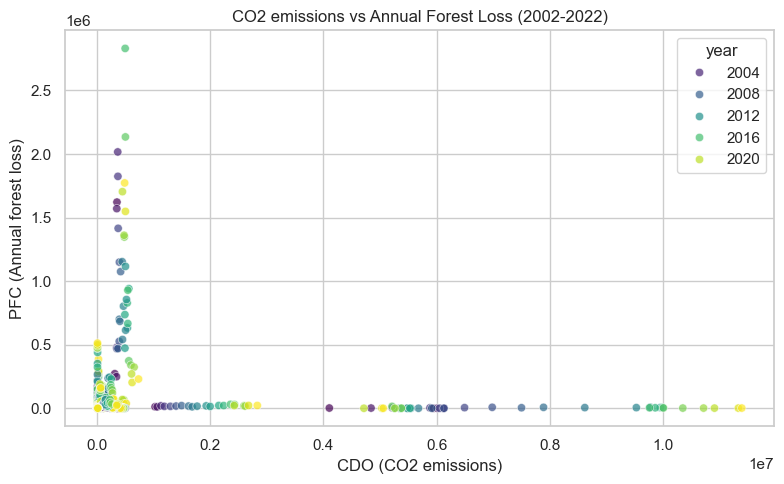

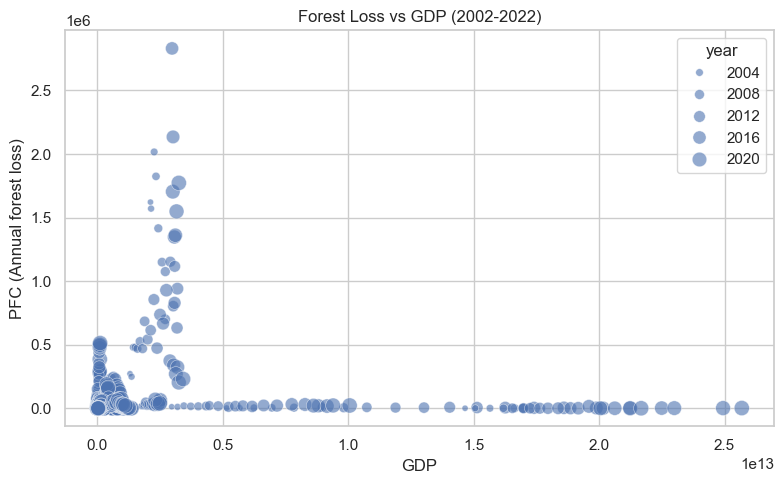

In [6]:
# Prepare data for a few key scatter plots
plot_df = window.pivot_table(index=['country', 'year'], columns='metric', values='value').reset_index()
plot_df = plot_df[['country', 'year', 'PFC', 'CDO', 'GDP', 'SHI', 'FSS', 'BTO', 'BTZ']]

# Scatter: CO2 emissions vs annual forest loss
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='CDO', y='PFC', hue='year', palette='viridis', legend='brief', alpha=0.7)
plt.title('CO2 emissions vs Annual Forest Loss (2002-2022)')
plt.xlabel('CDO (CO2 emissions)')
plt.ylabel('PFC (Annual forest loss)')
plt.tight_layout()
plt.show()

# Scatter: GDP as color around forest loss and biodiversity measure
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='GDP', y='PFC', size='year', sizes=(20, 120), alpha=0.6)
plt.title('Forest Loss vs GDP (2002-2022)')
plt.xlabel('GDP')
plt.ylabel('PFC (Annual forest loss)')
plt.tight_layout()
plt.show()

## Next steps
- Refine the modeling path with a chosen dependent variable and moderator.
- Consider `PFC ~ CDO` with `GDP` as a moderator.
- Alternatively, explore biodiversity outcomes like `RLI` or `SHI` as ecological damage measures.
- Decide whether to use `BTO` / `BTZ` to explore fisheries impact in ocean-dependent countries.